# Data Integration Lab - TechTrove E-Commerce


In [3]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

pd.set_option("display.width", 120)

# เก็บ log ของทุกขั้นตอนที่กระทบจำนวนแถว/คุณภาพข้อมูล เพื่อสร้าง Data Quality Report ที่ตรวจสอบย้อนกลับได้
dq_log = []


def log_dq(step, description, rows_before, rows_after, reason=""):
    """บันทึกทุกการเปลี่ยนแปลงจำนวนแถว พร้อมเหตุผล (กติกาข้อ 6: ห้ามลบ/แก้โดยไม่บันทึก)"""
    dq_log.append(
        {
            "step": step,
            "description": description,
            "rows_before": rows_before,
            "rows_after": rows_after,
            "rows_affected": rows_before - rows_after,
            "reason": reason,
        }
    )
    print(f"[{step}] {description}: {rows_before} -> {rows_after} "
          f"(affected={rows_before - rows_after}) | {reason}")


def profile_df(name, df):
    """TODO 1 helper: สำรวจคุณภาพข้อมูลเบื้องต้นก่อนแก้ไขอะไรทั้งสิ้น"""
    print(f"\n{'='*70}\nPROFILE: {name}\n{'='*70}")
    print(f"shape: {df.shape}")
    print(f"columns/dtypes:\n{df.dtypes}")
    print(f"missing values:\n{df.isna().sum()}")
    print(f"duplicate rows (exact): {df.duplicated().sum()}")
    if "order_id" in df.columns:
        print(f"duplicate order_id: {df['order_id'].duplicated().sum()}")
    if "customer_id" in df.columns and name == "customers_crm":
        print(f"duplicate customer_id: {df['customer_id'].duplicated().sum()}")
    print(f"sample rows:\n{df.head(3).to_string()}")

## TODO 1: Extract & Profile (5.1)
อ่านข้อมูลจาก CSV, Excel และ nested JSON แล้วสำรวจคุณภาพข้อมูลเบื้องต้น (shape, dtype, missing, duplicate, ตัวอย่างค่า) **ก่อนแก้ไขอะไรทั้งสิ้น**

In [4]:
orders_01_raw = pd.read_csv("orders_2026_01.csv")
orders_02_raw = pd.read_csv("orders_2026_02.csv")
customers_raw = pd.read_csv("customers_crm.csv")
products_raw = pd.read_excel("product_master.xlsx")
with open("payments.json", encoding="utf-8") as f:
    payments_json = json.load(f)
payments_raw = pd.json_normalize(payments_json)

profile_df("orders_2026_01", orders_01_raw)
profile_df("orders_2026_02", orders_02_raw)
profile_df("customers_crm", customers_raw)
profile_df("product_master", products_raw)
profile_df("payments", payments_raw)

raw_total_rows = {
    "orders_2026_01": len(orders_01_raw),
    "orders_2026_02": len(orders_02_raw),
    "customers_crm": len(customers_raw),
    "product_master": len(products_raw),
    "payments": len(payments_raw),
}


PROFILE: orders_2026_01
shape: (361, 8)
columns/dtypes:
order_id        object
order_date      object
customer_id     object
product_id      object
quantity         int64
unit_price     float64
discount       float64
channel         object
dtype: object
missing values:
order_id       0
order_date     0
customer_id    0
product_id     0
quantity       0
unit_price     1
discount       0
channel        0
dtype: int64
duplicate rows (exact): 1
duplicate order_id: 1
sample rows:
    order_id           order_date customer_id product_id  quantity  unit_price  discount      channel
0  ORD000001  2026-01-08 17:11:00       C0158       P039         2       940.5      0.00  Marketplace
1  ORD000002  2026-01-12 20:13:00       C0123       P038         1     12900.0      0.10   Mobile App
2  ORD000003  2026-01-26 14:00:00       C0119       P031         3      1415.5      0.05          Web

PROFILE: orders_2026_02
shape: (391, 8)
columns/dtypes:
order_id         object
ordered_at       object
custom

## TODO 2: Schema Alignment + Combine Orders (5.2)
ไฟล์ ก.พ. ใช้ชื่อคอลัมน์ต่างกัน (`ordered_at`/`qty`/`discount_pct`), วันที่เป็น `DD/MM/YYYY HH:MM`, ส่วนลดเป็น string เปอร์เซ็นต์ ("5%")
ต้องปรับให้ตรงกับ ม.ค. ก่อน แล้วจึง `pd.concat(..., ignore_index=True)`

In [5]:
orders_02_aligned = orders_02_raw.rename(
    columns={"ordered_at": "order_date", "qty": "quantity", "discount_pct": "discount"}
).copy()

# ม.ค.: order_date เป็น ISO string (YYYY-MM-DD HH:MM:SS) -> parse ตรงๆ
# ก.พ.: order_date เดิมเป็น DD/MM/YYYY HH:MM -> ต้อง dayfirst
orders_01_aligned = orders_01_raw.copy()
orders_01_aligned["order_date"] = pd.to_datetime(orders_01_aligned["order_date"])
orders_02_aligned["order_date"] = pd.to_datetime(
    orders_02_aligned["order_date"], format="%d/%m/%Y %H:%M"
)

# ม.ค.: discount เป็นสัดส่วน (0.05) อยู่แล้ว
# ก.พ.: discount เป็น string เปอร์เซ็นต์ ("5%") -> แปลงเป็นสัดส่วน
orders_02_aligned["discount"] = (
    orders_02_aligned["discount"].str.rstrip("%").astype(float) / 100
)

assert list(orders_01_aligned.columns) == list(orders_02_aligned.columns), \
    "schema ของ orders สองเดือนยังไม่ตรงกัน"

orders_combined = pd.concat([orders_01_aligned, orders_02_aligned], ignore_index=True)
log_dq(
    "2. Combine orders",
    "concat orders_01 + orders_02 (schema aligned: rename cols, parse date, % -> proportion)",
    len(orders_01_raw) + len(orders_02_raw),
    len(orders_combined),
    "ไม่มีแถวถูกตัดในขั้นนี้ เป็นการรวมไฟล์เท่านั้น",
)
orders_combined.head()

[2. Combine orders] concat orders_01 + orders_02 (schema aligned: rename cols, parse date, % -> proportion): 752 -> 752 (affected=0) | ไม่มีแถวถูกตัดในขั้นนี้ เป็นการรวมไฟล์เท่านั้น


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel
0,ORD000001,2026-01-08 17:11:00,C0158,P039,2,940.5,0.00,Marketplace
1,ORD000002,2026-01-12 20:13:00,C0123,P038,1,12900.0,0.10,Mobile App
2,ORD000003,2026-01-26 14:00:00,C0119,P031,3,1415.5,0.05,Web
3,ORD000004,2026-01-18 16:18:00,C0065,P003,2,25900.0,0.00,Mobile App
4,ORD000005,2026-01-08 17:43:00,C0129,P007,2,23310.0,0.05,Mobile App


## TODO 3: Transform - Clean / Standardize / Deduplicate (5.3)

### 3.1–3.2 Orders: ลบ exact-duplicate และ dedupe ตาม `order_id` (กติกาข้อ 1: เก็บแถวล่าสุดตามลำดับที่ปรากฏ)

In [6]:
before = len(orders_combined)
orders_dedup = orders_combined.drop_duplicates()
log_dq(
    "3.1 Orders exact dup",
    "drop_duplicates() ทั้งแถวเหมือนกันทุก column",
    before,
    len(orders_dedup),
    "แถวซ้ำเดิม (มาจากการ append ผิดพลาดในระบบต้นทาง)",
)

before = len(orders_dedup)
orders_dedup = orders_dedup.sort_values("order_date").drop_duplicates(
    subset="order_id", keep="last"
).sort_index()
log_dq(
    "3.2 Orders dup order_id",
    "drop_duplicates(subset='order_id', keep='last') ตามกติกาข้อ 1",
    before,
    len(orders_dedup),
    "order_id ซ้ำ เก็บแถวล่าสุดตามลำดับที่ปรากฏ",
)

[3.1 Orders exact dup] drop_duplicates() ทั้งแถวเหมือนกันทุก column: 752 -> 750 (affected=2) | แถวซ้ำเดิม (มาจากการ append ผิดพลาดในระบบต้นทาง)
[3.2 Orders dup order_id] drop_duplicates(subset='order_id', keep='last') ตามกติกาข้อ 1: 750 -> 750 (affected=0) | order_id ซ้ำ เก็บแถวล่าสุดตามลำดับที่ปรากฏ


### 3.3 Orders: แปลงชนิดข้อมูลให้ถูกต้อง และ trim string keys

In [7]:
orders_clean = orders_dedup.copy()
orders_clean["quantity"] = pd.to_numeric(orders_clean["quantity"], errors="coerce").astype("Int64")
orders_clean["unit_price"] = pd.to_numeric(orders_clean["unit_price"], errors="coerce")
orders_clean["discount"] = pd.to_numeric(orders_clean["discount"], errors="coerce")
orders_clean["customer_id"] = orders_clean["customer_id"].str.strip()
orders_clean["product_id"] = orders_clean["product_id"].str.strip()
orders_clean["channel"] = orders_clean["channel"].str.strip()
orders_clean.dtypes

,0
order_id,object
order_date,datetime64[ns]
customer_id,object
product_id,object
quantity,Int64
unit_price,float64
discount,float64
channel,object


### 3.4 Customers: lower/trim email, ทำจังหวัดให้เป็นมาตรฐาน, ลบข้อมูลซ้ำ

In [8]:
customers_clean = customers_raw.copy()
customers_clean["email"] = customers_clean["email"].str.strip().str.lower()

province_map = {
    "chonburi": "ชลบุรี",
    "ชลบุรี": "ชลบุรี",
    "khon kaen": "ขอนแก่น",
    "ขอนแก่น": "ขอนแก่น",
    "ขอนเเก่น": "ขอนแก่น",  # สระ เ กับ แ พิมพ์ผิด
    "bangkok": "กรุงเทพมหานคร",
    "กรุงเทพมหานคร": "กรุงเทพมหานคร",
    "กทม.": "กรุงเทพมหานคร",
    "กทม": "กรุงเทพมหานคร",
    "rayong": "ระยอง",
    "ระยอง": "ระยอง",
    "phuket": "ภูเก็ต",
    "ภูเก็ต": "ภูเก็ต",
    "chiang mai": "เชียงใหม่",
    "เชียงใหม่": "เชียงใหม่",
}


def standardize_province(value):
    if pd.isna(value):
        return value
    key = value.strip().lower()
    return province_map.get(key, value.strip())


before_provinces = customers_clean["province"].nunique()
customers_clean["province"] = customers_clean["province"].apply(standardize_province)
after_provinces = customers_clean["province"].nunique()
log_dq(
    "3.3 Province standardize",
    "รวมชื่อจังหวัด TH/EN/พิมพ์ผิด/เว้นวรรค ให้เหลือชื่อมาตรฐานเดียว",
    before_provinces,
    after_provinces,
    "จำนวน unique province values ก่อน/หลัง (ไม่ใช่จำนวนแถว)",
)

before = len(customers_clean)
customers_clean = customers_clean.drop_duplicates().sort_values(
    "signup_date"
).drop_duplicates(subset="customer_id", keep="last").sort_index()
log_dq(
    "3.4 Customers dedup",
    "ลบแถวลูกค้าซ้ำ (exact dup + dup customer_id, เก็บแถวล่าสุด)",
    before,
    len(customers_clean),
    "customer_id ซ้ำ 3 ราย เกิดจากแถว trailing-space/uppercase email ที่ต่อท้ายไฟล์",
)
customers_clean.head()

[3.3 Province standardize] รวมชื่อจังหวัด TH/EN/พิมพ์ผิด/เว้นวรรค ให้เหลือชื่อมาตรฐานเดียว: 14 -> 6 (affected=8) | จำนวน unique province values ก่อน/หลัง (ไม่ใช่จำนวนแถว)
[3.4 Customers dedup] ลบแถวลูกค้าซ้ำ (exact dup + dup customer_id, เก็บแถวล่าสุด): 163 -> 160 (affected=3) | customer_id ซ้ำ 3 ราย เกิดจากแถว trailing-space/uppercase email ที่ต่อท้ายไฟล์


,customer_id,full_name,email,province,signup_date
0,C0001,ลูกค้า 001,customer001@example.com,ชลบุรี,2024-07-29
1,C0002,ลูกค้า 002,customer002@example.com,ชลบุรี,2025-01-04
2,C0003,ลูกค้า 003,customer003@example.com,ขอนแก่น,2025-10-10
3,C0004,ลูกค้า 004,customer004@example.com,กรุงเทพมหานคร,2024-07-11
4,C0005,ลูกค้า 005,customer005@example.com,ระยอง,2025-06-27


### 3.5 Products: trim string columns (profiling ไม่พบปัญหาสำคัญอื่น)

In [9]:
products_clean = products_raw.copy()
products_clean["product_id"] = products_clean["product_id"].str.strip()
products_clean["category"] = products_clean["category"].str.strip()
products_clean["active_flag"] = products_clean["active_flag"].str.strip().str.upper()
products_clean.head()

,product_id,product_name,category,standard_price,active_flag
0,P001,Notebook Model 01,Notebook,299,Y
1,P002,Smartphone Model 02,Smartphone,1490,Y
2,P003,Smartphone Model 03,Smartphone,25900,Y
3,P004,Smart Home Model 04,Smart Home,1490,Y
4,P005,Smartphone Model 05,Smartphone,299,Y


### 3.6 Payments: flatten nested JSON แล้วลบ exact-duplicate

In [10]:
payments_clean = payments_raw.rename(
    columns={"payment.method": "payment_method", "payment.status": "payment_status"}
).copy()
payments_clean["paid_at"] = pd.to_datetime(payments_clean["paid_at"])
before = len(payments_clean)
payments_clean = payments_clean.drop_duplicates()
log_dq(
    "3.5 Payments exact dup",
    "drop_duplicates() บน nested JSON ที่ flatten แล้ว",
    before,
    len(payments_clean),
    "แถว payment ซ้ำทั้ง payment_id/order_id",
)
payments_clean.head()

[3.5 Payments exact dup] drop_duplicates() บน nested JSON ที่ flatten แล้ว: 752 -> 751 (affected=1) | แถว payment ซ้ำทั้ง payment_id/order_id


,payment_id,order_id,paid_at,payment_method,payment_status
0,PAY000001,ORD000001,2026-01-08 17:30:00,Bank Transfer,PAID
1,PAY000002,ORD000002,2026-01-12 22:58:00,Bank Transfer,PAID
2,PAY000003,ORD000003,2026-01-26 14:03:00,PromptPay,PAID
3,PAY000004,ORD000004,2026-01-18 18:24:00,Bank Transfer,PAID
4,PAY000005,ORD000005,2026-01-08 20:03:00,Credit Card,PAID


### 3.7 Orders: flag ค่าที่ผิดกติกาธุรกิจ (ยังไม่ลบ แค่บันทึกไว้ก่อนตามกติกาข้อ 6)

In [11]:
invalid_qty = (orders_clean["quantity"].isna()) | (orders_clean["quantity"] <= 0)
invalid_price = (orders_clean["unit_price"].isna()) | (orders_clean["unit_price"] <= 0)
invalid_discount = (
    orders_clean["discount"].isna()
    | (orders_clean["discount"] < 0)
    | (orders_clean["discount"] > 1)
)
log_dq(
    "3.6 Flag: quantity<=0/NaN",
    "ระบุ (ยังไม่ลบ) แถวที่ quantity ผิดกติกาข้อ 2",
    len(orders_clean),
    len(orders_clean) - invalid_qty.sum(),
    f"พบ {invalid_qty.sum()} แถว",
)
log_dq(
    "3.6 Flag: unit_price<=0/NaN",
    "ระบุ (ยังไม่ลบ) แถวที่ unit_price ผิดกติกาข้อ 2",
    len(orders_clean),
    len(orders_clean) - invalid_price.sum(),
    f"พบ {invalid_price.sum()} แถว",
)
log_dq(
    "3.6 Flag: discount out of [0,1]",
    "ระบุ (ยังไม่ลบ) แถวที่ discount ผิดกติกาข้อ 2",
    len(orders_clean),
    len(orders_clean) - invalid_discount.sum(),
    f"พบ {invalid_discount.sum()} แถว",
)
orders_clean["is_valid_values"] = ~(invalid_qty | invalid_price | invalid_discount)

[3.6 Flag: quantity<=0/NaN] ระบุ (ยังไม่ลบ) แถวที่ quantity ผิดกติกาข้อ 2: 750 -> 748 (affected=2) | พบ 2 แถว
[3.6 Flag: unit_price<=0/NaN] ระบุ (ยังไม่ลบ) แถวที่ unit_price ผิดกติกาข้อ 2: 750 -> 748 (affected=2) | พบ 2 แถว
[3.6 Flag: discount out of [0,1]] ระบุ (ยังไม่ลบ) แถวที่ discount ผิดกติกาข้อ 2: 750 -> 750 (affected=0) | พบ 0 แถว


## TODO 4: Integrate - merge ลูกค้า/สินค้า/การชำระเงิน พร้อม `validate=` และ `indicator=True` (5.4)

In [12]:
merged = orders_clean.merge(
    customers_clean[["customer_id", "full_name", "email", "province"]],
    on="customer_id",
    how="left",
    indicator="_customer_match",
    validate="m:1",
)
customer_unmatched = (merged["_customer_match"] == "left_only").sum()
log_dq(
    "4.1 Merge customers",
    "merge orders <- customers (left, validate m:1, indicator)",
    len(merged),
    len(merged),
    f"customer_id ไม่พบใน Master Data: {customer_unmatched} แถว",
)

merged = merged.merge(
    products_clean[["product_id", "product_name", "category", "standard_price", "active_flag"]],
    on="product_id",
    how="left",
    indicator="_product_match",
    validate="m:1",
)
product_unmatched = (merged["_product_match"] == "left_only").sum()
log_dq(
    "4.2 Merge products",
    "merge orders <- products (left, validate m:1, indicator)",
    len(merged),
    len(merged),
    f"product_id ไม่พบใน Master Data: {product_unmatched} แถว",
)

merged = merged.merge(
    payments_clean[["order_id", "payment_method", "payment_status", "paid_at"]],
    on="order_id",
    how="left",
    indicator="_payment_match",
    validate="1:1",
)
payment_unmatched = (merged["_payment_match"] == "left_only").sum()
orphan_payments = (~payments_clean["order_id"].isin(orders_clean["order_id"])).sum()
log_dq(
    "4.3 Merge payments",
    "merge orders <- payments (left, validate 1:1, indicator)",
    len(merged),
    len(merged),
    f"order ที่ไม่มี payment record: {payment_unmatched} แถว | "
    f"payment ที่ orphan (ไม่มี order อ้างอิง): {orphan_payments} แถว",
)
merged.head()

[4.1 Merge customers] merge orders <- customers (left, validate m:1, indicator): 750 -> 750 (affected=0) | customer_id ไม่พบใน Master Data: 22 แถว
[4.2 Merge products] merge orders <- products (left, validate m:1, indicator): 750 -> 750 (affected=0) | product_id ไม่พบใน Master Data: 2 แถว
[4.3 Merge payments] merge orders <- payments (left, validate 1:1, indicator): 750 -> 750 (affected=0) | order ที่ไม่มี payment record: 0 แถว | payment ที่ orphan (ไม่มี order อ้างอิง): 1 แถว


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,channel,is_valid_values,full_name,...,_customer_match,product_name,category,standard_price,active_flag,_product_match,payment_method,payment_status,paid_at,_payment_match
0,ORD000001,2026-01-08 17:11:00,C0158,P039,2,940.5,0.00,Marketplace,True,ลูกค้า 158,...,both,Notebook Model 39,Notebook,990.0,N,both,Bank Transfer,PAID,2026-01-08 17:30:00,both
1,ORD000002,2026-01-12 20:13:00,C0123,P038,1,12900.0,0.10,Mobile App,True,ลูกค้า 123,...,both,Smartphone Model 38,Smartphone,12900.0,N,both,Bank Transfer,PAID,2026-01-12 22:58:00,both
2,ORD000003,2026-01-26 14:00:00,C0119,P031,3,1415.5,0.05,Web,True,ลูกค้า 119,...,both,Smart Home Model 31,Smart Home,1490.0,Y,both,PromptPay,PAID,2026-01-26 14:03:00,both
3,ORD000004,2026-01-18 16:18:00,C0065,P003,2,25900.0,0.00,Mobile App,True,ลูกค้า 065,...,both,Smartphone Model 03,Smartphone,25900.0,Y,both,Bank Transfer,PAID,2026-01-18 18:24:00,both
4,ORD000005,2026-01-08 17:43:00,C0129,P007,2,23310.0,0.05,Mobile App,True,ลูกค้า 129,...,both,Notebook Model 07,Notebook,25900.0,Y,both,Credit Card,PAID,2026-01-08 20:03:00,both


## TODO 5: Validate ตามกติกาทางธุรกิจ ก่อนคำนวณยอดขาย (5.4 ต่อ)
นับเป็นยอดขายเมื่อ: ค่าถูกต้องตามกติกาข้อ 2 + จับคู่ customer/product/payment ได้ครบ + `payment_status == "PAID"`

In [13]:
is_matched = (
    (merged["_customer_match"] == "both")
    & (merged["_product_match"] == "both")
    & (merged["_payment_match"] == "both")
)
is_paid = merged["payment_status"] == "PAID"
is_valid_sale = merged["is_valid_values"] & is_matched & is_paid

before = len(merged)
log_dq(
    "5.1 Validate: unmatched",
    "แถวที่ customer หรือ product หรือ payment ไม่พบ (unmatched)",
    before,
    int(is_matched.sum()),
    f"unmatched customer={customer_unmatched}, product={product_unmatched}, payment={payment_unmatched}",
)
log_dq(
    "5.2 Validate: not PAID",
    "แถวที่ payment_status ไม่ใช่ PAID (กติกาข้อ 4)",
    before,
    int(is_paid.sum()),
    f"{(~is_paid).sum()} แถว (FAILED/REFUNDED/ไม่มี payment)",
)
log_dq(
    "5.3 Final valid sales",
    "แถวที่ผ่านครบทุกกติกา (value valid + matched + PAID) -> ใช้คำนวณยอดขาย",
    before,
    int(is_valid_sale.sum()),
    "นี่คือฐานข้อมูลของ fact_sales.csv",
)

merged["net_sales"] = merged["quantity"] * merged["unit_price"] * (1 - merged["discount"])

[5.1 Validate: unmatched] แถวที่ customer หรือ product หรือ payment ไม่พบ (unmatched): 750 -> 726 (affected=24) | unmatched customer=22, product=2, payment=0
[5.2 Validate: not PAID] แถวที่ payment_status ไม่ใช่ PAID (กติกาข้อ 4): 750 -> 686 (affected=64) | 64 แถว (FAILED/REFUNDED/ไม่มี payment)
[5.3 Final valid sales] แถวที่ผ่านครบทุกกติกา (value valid + matched + PAID) -> ใช้คำนวณยอดขาย: 750 -> 660 (affected=90) | นี่คือฐานข้อมูลของ fact_sales.csv


## TODO 6: Load - dim_customer, dim_product, fact_sales, data_quality_report

In [14]:
dim_customer = customers_clean.reset_index(drop=True).copy()
dim_customer.insert(0, "customer_key", range(1, len(dim_customer) + 1))

dim_product = products_clean.reset_index(drop=True).copy()
dim_product.insert(0, "product_key", range(1, len(dim_product) + 1))

fact_sales = merged.loc[
    is_valid_sale,
    [
        "order_id",
        "order_date",
        "customer_id",
        "product_id",
        "quantity",
        "unit_price",
        "discount",
        "net_sales",
        "channel",
        "payment_method",
        "paid_at",
        "province",
        "category",
    ],
].reset_index(drop=True)
fact_sales.insert(0, "sales_key", range(1, len(fact_sales) + 1))

dim_customer.to_csv(OUTPUT / "dim_customer.csv", index=False, encoding="utf-8-sig")
dim_product.to_csv(OUTPUT / "dim_product.csv", index=False, encoding="utf-8-sig")
fact_sales.to_csv(OUTPUT / "fact_sales.csv", index=False, encoding="utf-8-sig")

dq_report = pd.DataFrame(dq_log)
dq_report.to_csv(OUTPUT / "data_quality_report.csv", index=False, encoding="utf-8-sig")

print(f"dim_customer: {dim_customer.shape}")
print(f"dim_product:  {dim_product.shape}")
print(f"fact_sales:   {fact_sales.shape}")
fact_sales.head()

dim_customer: (160, 6)
dim_product:  (40, 6)
fact_sales:   (660, 14)


,sales_key,order_id,order_date,customer_id,product_id,quantity,unit_price,discount,net_sales,channel,payment_method,paid_at,province,category
0,1,ORD000001,2026-01-08 17:11:00,C0158,P039,2,940.5,0.00,1881.0,Marketplace,Bank Transfer,2026-01-08 17:30:00,เชียงใหม่,Notebook
1,2,ORD000002,2026-01-12 20:13:00,C0123,P038,1,12900.0,0.10,11610.0,Mobile App,Bank Transfer,2026-01-12 22:58:00,ระยอง,Smartphone
2,3,ORD000003,2026-01-26 14:00:00,C0119,P031,3,1415.5,0.05,4034.175,Web,PromptPay,2026-01-26 14:03:00,ขอนแก่น,Smart Home
3,4,ORD000004,2026-01-18 16:18:00,C0065,P003,2,25900.0,0.00,51800.0,Mobile App,Bank Transfer,2026-01-18 18:24:00,ขอนแก่น,Smartphone
4,5,ORD000005,2026-01-08 17:43:00,C0129,P007,2,23310.0,0.05,44289.0,Mobile App,Credit Card,2026-01-08 20:03:00,กรุงเทพมหานคร,Notebook


## TODO 7: Analyze - summary_by_province.csv, summary_by_category.csv

In [15]:
summary_by_province = (
    fact_sales.groupby("province", as_index=False)
    .agg(transactions=("sales_key", "count"), net_sales=("net_sales", "sum"))
    .sort_values("net_sales", ascending=False)
)
summary_by_category = (
    fact_sales.groupby("category", as_index=False)
    .agg(transactions=("sales_key", "count"), net_sales=("net_sales", "sum"))
    .sort_values("net_sales", ascending=False)
)
summary_by_province.to_csv(OUTPUT / "summary_by_province.csv", index=False, encoding="utf-8-sig")
summary_by_category.to_csv(OUTPUT / "summary_by_category.csv", index=False, encoding="utf-8-sig")

print("Summary by province:")
display(summary_by_province)
print("\nSummary by category:")
display(summary_by_category)

Summary by province:


,province,transactions,net_sales
0,กรุงเทพมหานคร,154,2612955.87
1,ขอนแก่น,110,2031943.385
4,ระยอง,120,1523168.615
5,เชียงใหม่,104,1477338.0075
3,ภูเก็ต,86,1427388.735
2,ชลบุรี,86,1151249.465



Summary by category:


,category,transactions,net_sales
3,Smartphone,178,3092117.3425
0,Accessory,180,2710582.78
1,Notebook,161,2221495.4875
2,Smart Home,141,2199848.4675


## Challenge (+2 คะแนน): `validate_data()` + Data Quality Funnel

In [16]:
def validate_data(df):
    """ตรวจสอบ uniqueness, referential integrity, และค่านอกช่วง ด้วย assert/exception"""
    errors = []
    if df["order_id"].duplicated().any():
        errors.append("order_id ไม่ unique")
    if "quantity" in df and (df["quantity"] <= 0).any():
        errors.append("พบ quantity <= 0")
    if "unit_price" in df and ((df["unit_price"] <= 0) | df["unit_price"].isna()).any():
        errors.append("พบ unit_price <= 0 หรือว่าง")
    if "discount" in df and ((df["discount"] < 0) | (df["discount"] > 1)).any():
        errors.append("พบ discount นอกช่วง [0,1]")
    if errors:
        raise AssertionError("; ".join(errors))
    return True


try:
    validate_data(fact_sales)
    print("validate_data(fact_sales): PASSED (fact_sales สะอาดตามกติกาทั้งหมด)")
except AssertionError as e:
    print(f"validate_data(fact_sales): FAILED -> {e}")

validate_data(fact_sales): PASSED (fact_sales สะอาดตามกติกาทั้งหมด)


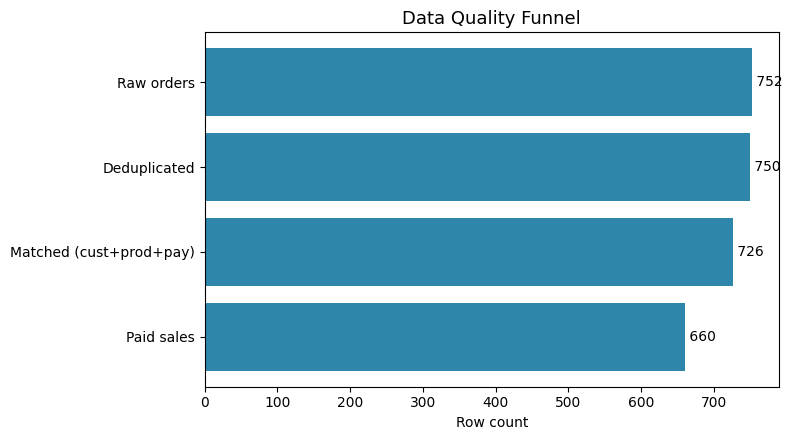

In [17]:
funnel_labels = ["Raw orders", "Deduplicated", "Matched (cust+prod+pay)", "Paid sales"]
funnel_values = [
    raw_total_rows["orders_2026_01"] + raw_total_rows["orders_2026_02"],
    len(orders_clean),
    int(is_matched.sum()),
    int(is_valid_sale.sum()),
]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(funnel_labels[::-1], funnel_values[::-1], color="#2E86AB")
for i, v in enumerate(funnel_values[::-1]):
    ax.text(v, i, f" {v}", va="center")
ax.set_xlabel("Row count")
ax.set_title("Data Quality Funnel", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT / "data_quality_funnel.png", dpi=150)
plt.show()

## คำตอบคำถามวิเคราะห์ 6 ข้อ (อ้างอิงตัวเลขจากการรันจริง)

In [18]:
q1 = len(orders_combined)
q1_after_dedup = len(orders_clean)
q2_customer_unmatched = customer_unmatched
q2_product_unmatched = product_unmatched
q3_transactions = int(is_valid_sale.sum())
q3_net_sales = fact_sales["net_sales"].sum()
q4_top_province = summary_by_province.iloc[0]
q5_top_category = summary_by_category.iloc[0]

answers = f"""
{'='*70}
คำตอบคำถามวิเคราะห์ (อ้างอิงตัวเลขจากการรันจริง)
{'='*70}
1) หลังรวมไฟล์ orders: {q1} แถว | หลังลบ duplicate (exact + order_id): {q1_after_dedup} แถว

2) customer_id ไม่พบใน Master Data: {q2_customer_unmatched} แถว
   product_id ไม่พบใน Master Data: {q2_product_unmatched} แถว

3) ยอดขายที่ใช้ได้จริง (valid values + matched + PAID): {q3_transactions} ธุรกรรม
   ยอดขายสุทธิรวม: {q3_net_sales:,.2f} บาท

4) จังหวัดที่มียอดขายสุทธิสูงสุด: {q4_top_province['province']}
   ({q4_top_province['net_sales']:,.2f} บาท, {q4_top_province['transactions']} ธุรกรรม)

5) หมวดสินค้าที่มียอดขายสุทธิสูงสุด: {q5_top_category['category']}
   ({q5_top_category['net_sales']:,.2f} บาท, {q5_top_category['transactions']} ธุรกรรม)

6) หากสลับลำดับ merge ก่อน cleaning:
   - ข้อมูลดิบยังมี exact-duplicate rows, order_id ซ้ำ, email/province ไม่มาตรฐาน,
     และ dtype ยังไม่ถูกต้อง (discount เป็น string "%" ในไฟล์ ก.พ., วันที่ยังไม่ parse)
   - merge บน key ที่ยังไม่ trim/clean (เช่น customer_id/product_id มีช่องว่างปน หรือ
     discount เป็น string) จะทำให้ validate='m:1'/'1:1' อาจ error หรือ silently
     สร้างแถวซ้ำ (fan-out) เพราะแถวซ้ำในต้นทางยังไม่ถูกลบ
   - ผลคือ net_sales จะถูกคำนวณผิด (นับแถวซ้ำซ้อน) และ unmatched count จะสูงเกินจริง
     เพราะ key ไม่ตรงกันจากปัญหา formatting ที่ยังไม่ได้ standardize
   - สรุป: ความเชื่อมั่นของข้อมูล (data trust) ลดลงอย่างมีนัยสำคัญ ควร clean ก่อน merge เสมอ
{'='*70}
"""
print(answers)

with open(OUTPUT / "analysis_answers.txt", "w", encoding="utf-8") as f:
    f.write(answers)

print("เสร็จสิ้น Data Integration Pipeline")
print(f"Output files อยู่ที่: {OUTPUT}")
for p in sorted(OUTPUT.iterdir()):
    print(f"  - {p.name}")


คำตอบคำถามวิเคราะห์ (อ้างอิงตัวเลขจากการรันจริง)
1) หลังรวมไฟล์ orders: 752 แถว | หลังลบ duplicate (exact + order_id): 750 แถว

2) customer_id ไม่พบใน Master Data: 22 แถว
   product_id ไม่พบใน Master Data: 2 แถว

3) ยอดขายที่ใช้ได้จริง (valid values + matched + PAID): 660 ธุรกรรม
   ยอดขายสุทธิรวม: 10,224,044.08 บาท

4) จังหวัดที่มียอดขายสุทธิสูงสุด: กรุงเทพมหานคร
   (2,612,955.87 บาท, 154 ธุรกรรม)

5) หมวดสินค้าที่มียอดขายสุทธิสูงสุด: Smartphone
   (3,092,117.34 บาท, 178 ธุรกรรม)

6) หากสลับลำดับ merge ก่อน cleaning:
   - ข้อมูลดิบยังมี exact-duplicate rows, order_id ซ้ำ, email/province ไม่มาตรฐาน,
     และ dtype ยังไม่ถูกต้อง (discount เป็น string "%" ในไฟล์ ก.พ., วันที่ยังไม่ parse)
   - merge บน key ที่ยังไม่ trim/clean (เช่น customer_id/product_id มีช่องว่างปน หรือ
     discount เป็น string) จะทำให้ validate='m:1'/'1:1' อาจ error หรือ silently
     สร้างแถวซ้ำ (fan-out) เพราะแถวซ้ำในต้นทางยังไม่ถูกลบ
   - ผลคือ net_sales จะถูกคำนวณผิด (นับแถวซ้ำซ้อน) และ unmatched count จะสูงเกิน